In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from arch import arch_model

In [3]:
data = pd.read_csv('data/ghana_gdp.csv', parse_dates=['year'], index_col=['year'])
data.head()

,GDP (current US$)
year,
1960-01-01,1.217087e+09
1961-01-01,0.000000e+00
1962-01-01,1.382353e+09
1963-01-01,1.540616e+09
1964-01-01,1.731092e+09


Text(0, 0.5, 'GDP (current US$)')

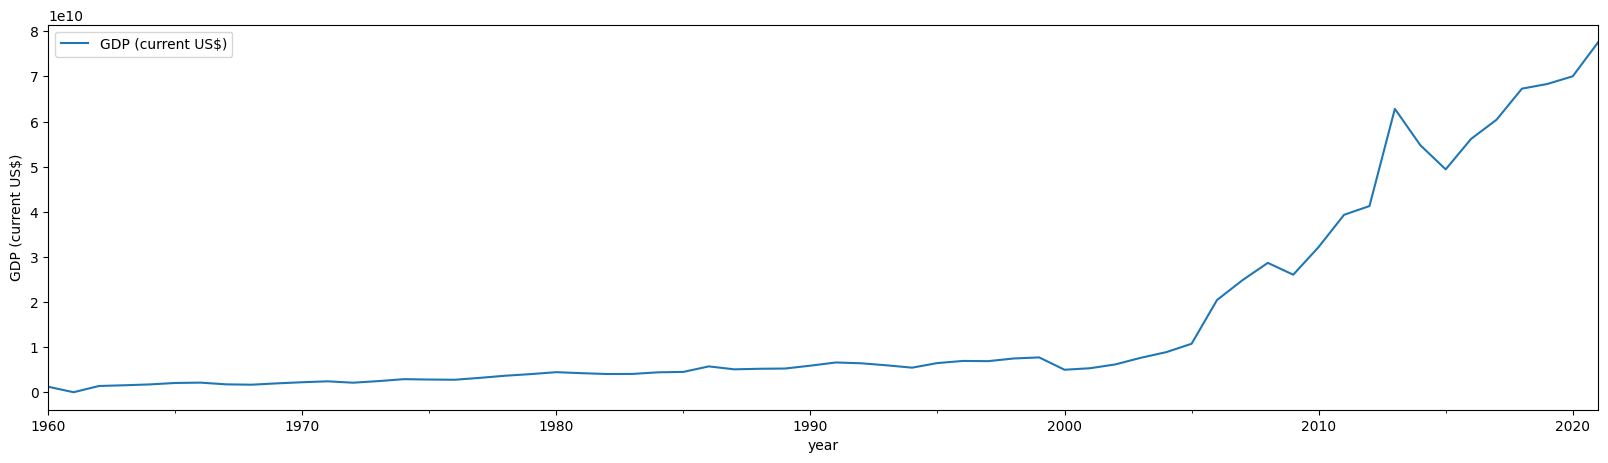

In [3]:
fig, ax = plt.subplots(figsize=(20,5))
data.plot(ax=ax)
ax.set_ylabel('GDP (current US$)')

In [ ]:
train_df = data.loc[:'2018-12-31']
test_df = data.loc['2019-01-01':]
train_df.shape, test_df.shape

((59, 1), (3, 1))

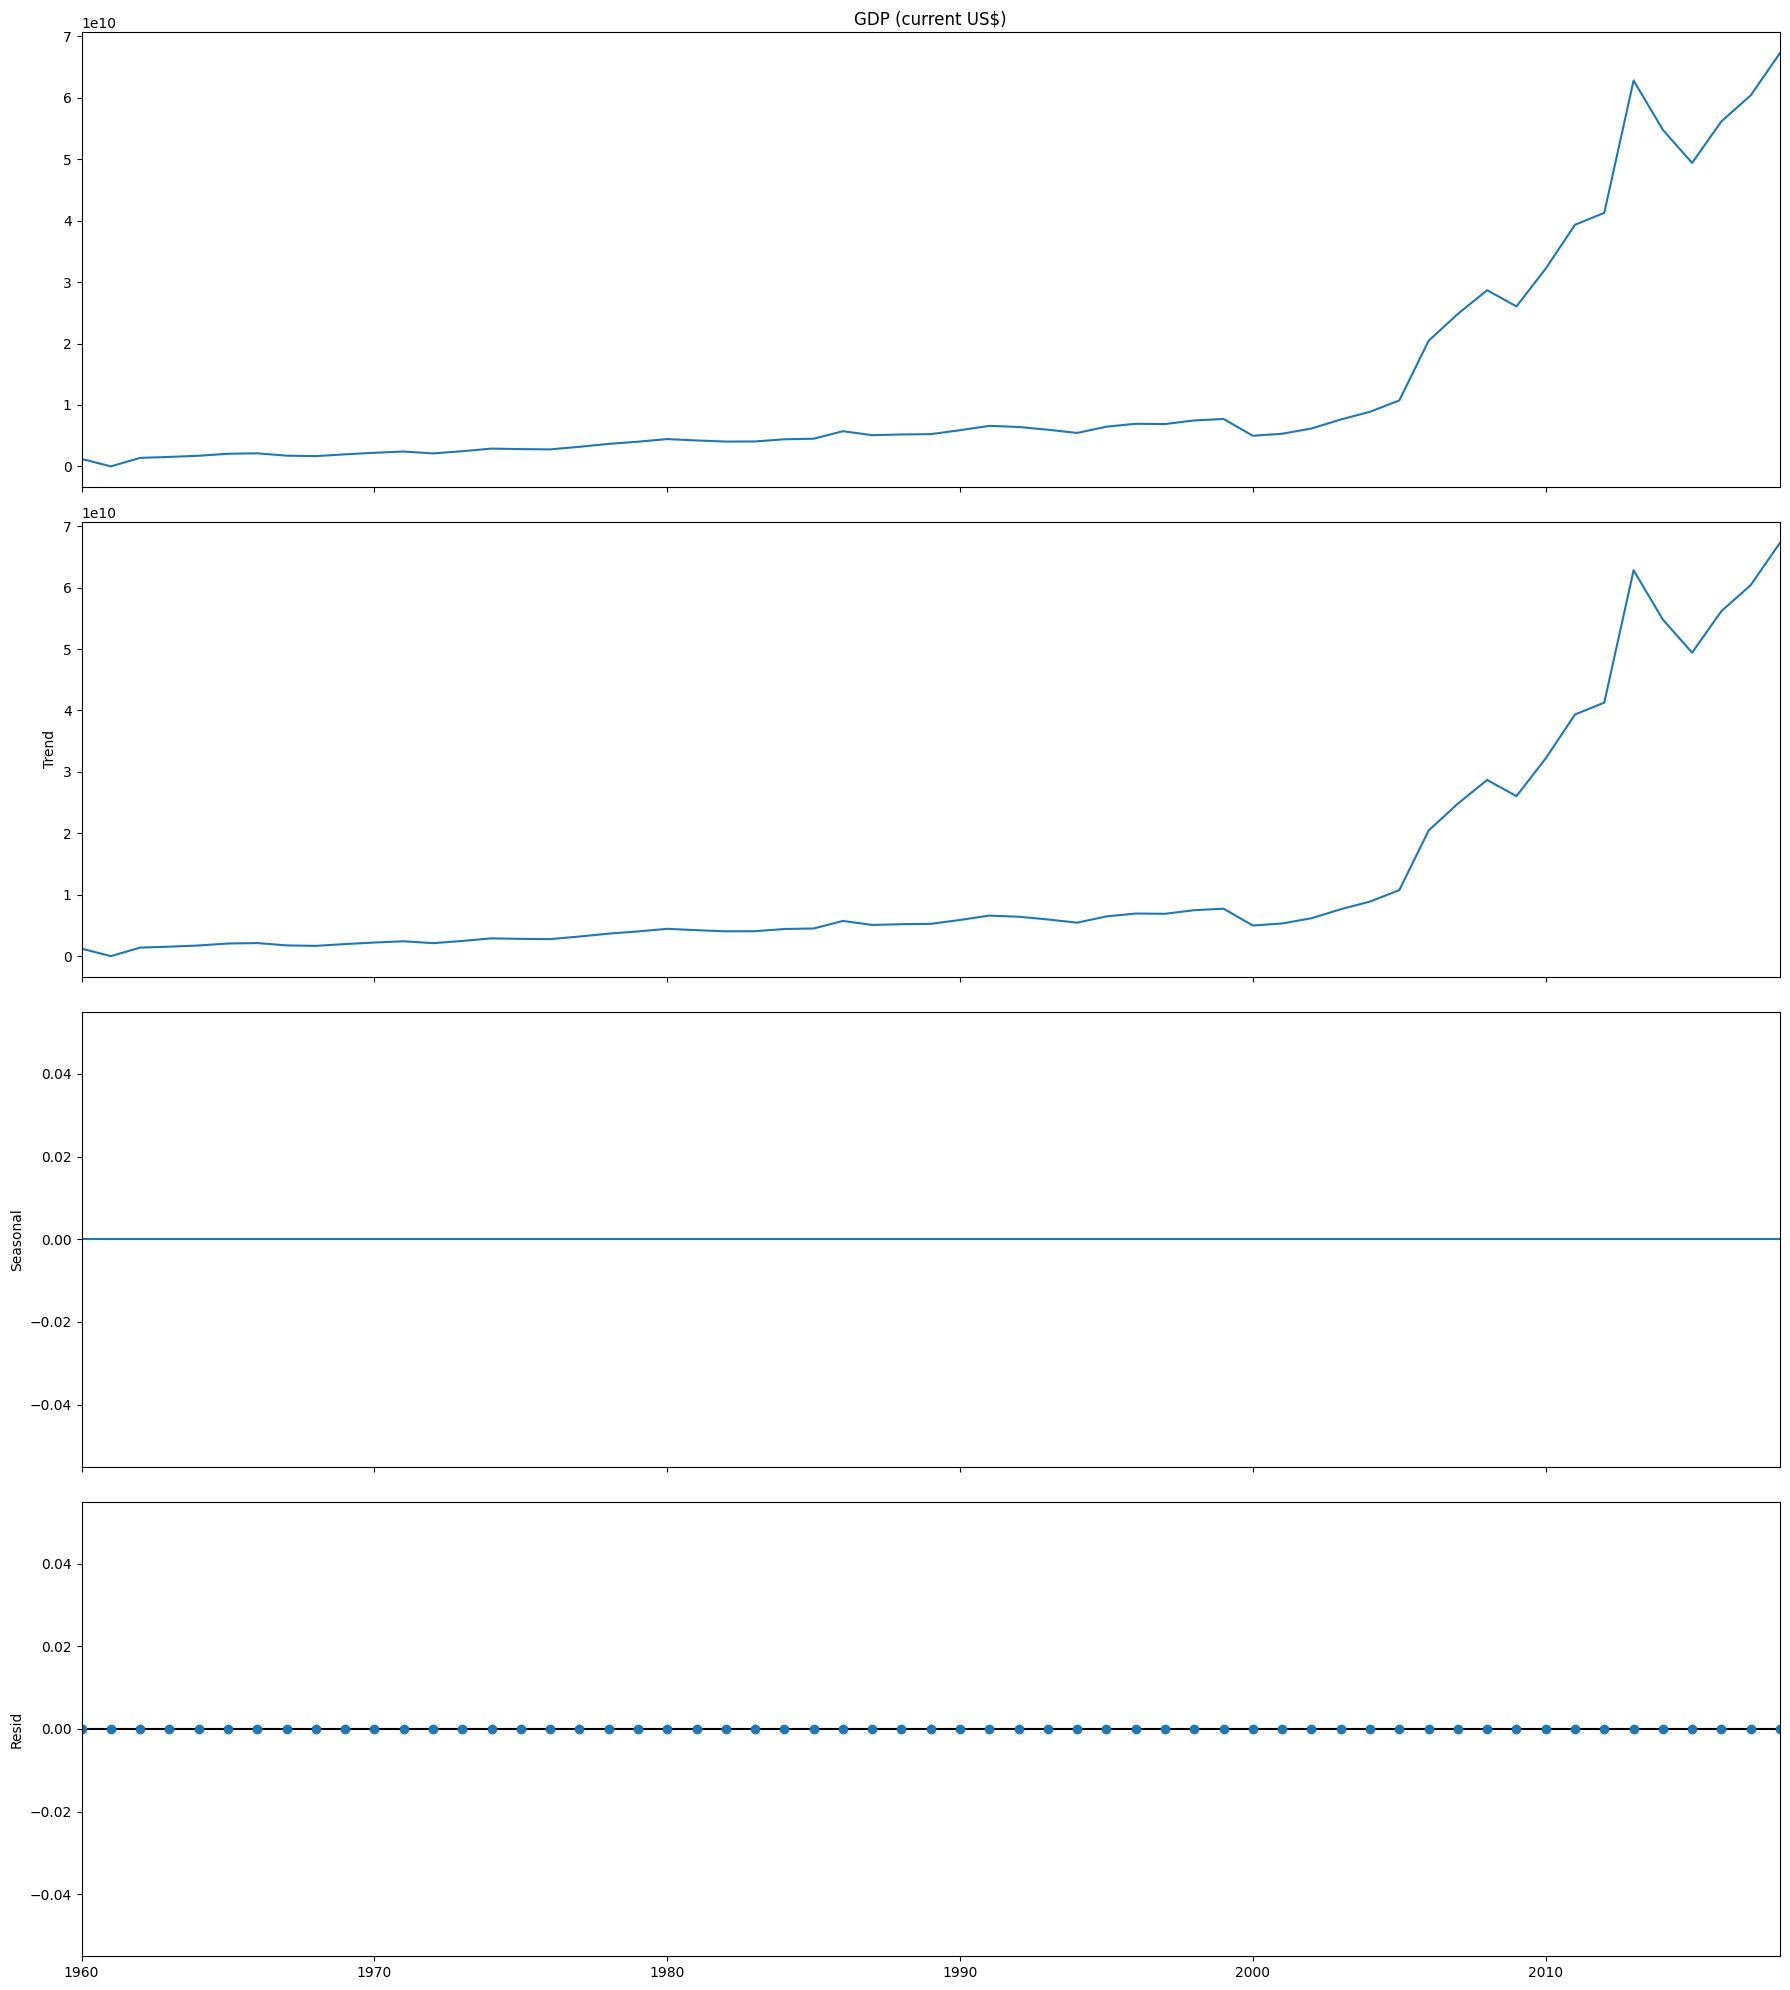

In [ ]:
plt.rcParams['figure.figsize'] = 18, 20

result = seasonal_decompose(train_df['GDP (current US$)'])
result.plot()
plt.show()

Во временном ряду присутствует компонента восходящего тренда и отсутствует компонент сезонности.

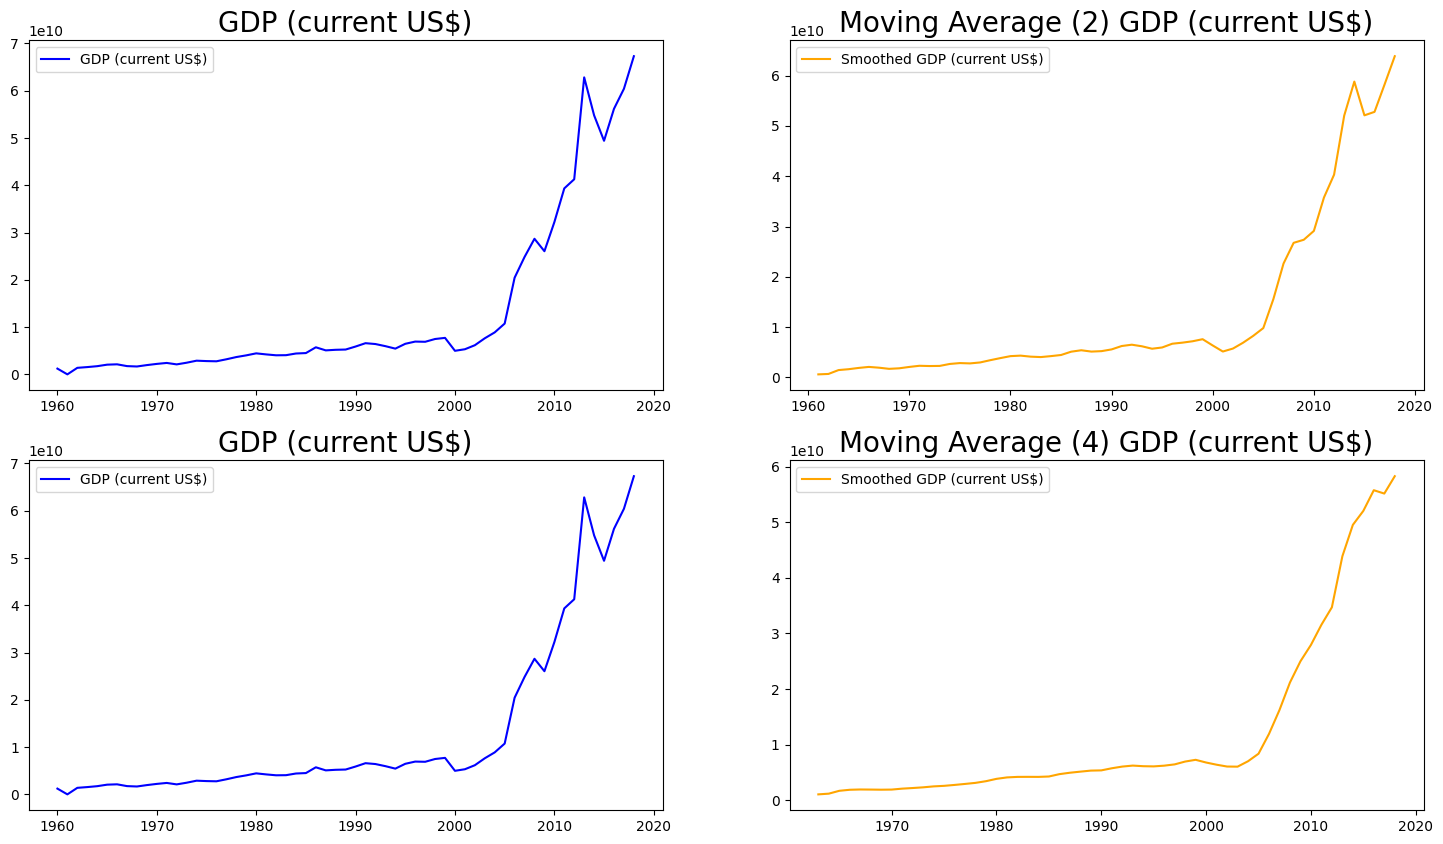

In [ ]:
plt.rcParams['figure.figsize'] = 18, 10

fig, ax = plt.subplots(2, 2)

# Окно в месяц (Window = 2)
ax[0, 0].plot(train_df['GDP (current US$)'], color='blue', label='GDP (current US$)')
ax[0, 0].set_title('GDP (current US$)', size=20)
ax[0, 0].legend()

ax[0, 1].plot(
    train_df['GDP (current US$)'].rolling(window=2).mean(),
    color='orange',
    label='Smoothed GDP (current US$)',
)

ax[0, 1].set_title('Moving Average (2) GDP (current US$)', size=20)
ax[0, 1].legend()


# Окно в год (Window = 4)
ax[1, 0].plot(train_df['GDP (current US$)'], color='blue', label="GDP (current US$)")
ax[1, 0].set_title('GDP (current US$)', size=20)
ax[1, 0].legend()

ax[1, 1].plot(
    train_df['GDP (current US$)'].rolling(window=4).mean(),
    color='orange',
    label='Smoothed GDP (current US$)',
)

ax[1, 1].set_title('Moving Average (4) GDP (current US$)', size=20)
ax[1, 1].legend()

plt.show()

Чем больший размер окна выбирается в качестве парметра скользящего среднего, тем сильнее сглаживаются периоды спада и становится наиболее выражен тренда роста валового продукта с течением времени.

In [54]:
def get_adfuller(df):
    test = adfuller(df)
    print('adf: ', test[0])
    print('p-value: ', test[1])
    print('Critical values: ', test[4])
    if test[0] > test[4]['5%']:
        print('ряд нестационарен')
    else:
        print('ряд стационарен')

In [8]:
get_adfuller(df=train_df)

adf:  0.6529066974885364
p-value:  0.9888496277665572
Critical values:  {'1%': -3.5745892596209488, '5%': -2.9239543084490744, '10%': -2.6000391840277777}
ряд нестационарен


In [ ]:
def plot_acf_pacf(series, n_lags):
    plt.rcParams['figure.figsize'] = 18, 5

    fig, axes = plt.subplots(1, 2)

    sgt.plot_acf(series, ax=axes[0], lags=n_lags)
    sgt.plot_pacf(series, ax=axes[1], lags=n_lags, method='ywm')
    plt.show()

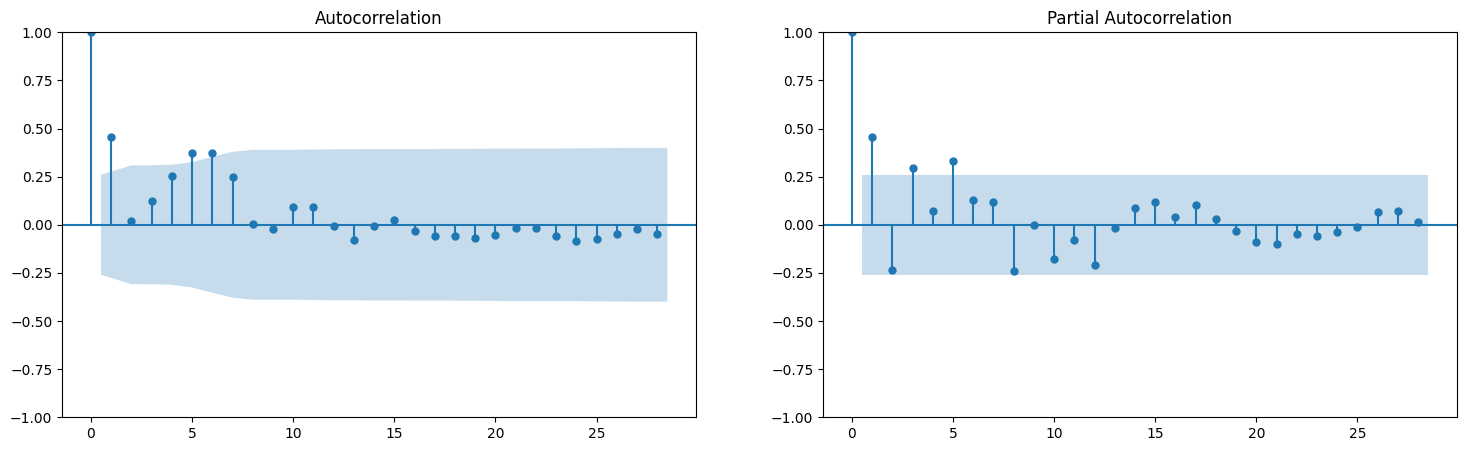

adf:  -3.5836708658260306
p-value:  0.006080989753876942
Critical values:  {'1%': -3.584828853223594, '5%': -2.9282991495198907, '10%': -2.6023438271604937}
ряд стационарен


In [ ]:
plot_acf_pacf(train_df['GDP (current US$)'].diff(2).dropna(), 28)

get_adfuller(train_df.diff(2).dropna())

In [ ]:
arima_model = ARIMA(train_df['GDP (current US$)'].dropna(), order=(1, 2, 1))
arima_model_fit = arima_model.fit()
arima_model_fit.summary()

c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      GDP (current US$)   No. Observations:                   59
Model:                 ARIMA(1, 2, 1)   Log Likelihood               -1339.208
Date:                Mon, 24 Feb 2025   AIC                           2684.416
Time:                        07:26:34   BIC                           2690.545
Sample:                    01-01-1960   HQIC                          2686.798
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1775      0.082     -2.159      0.031      -0.339      -0.016
ma.L1         -0.8688      0.046    -19.069      0.000      -0.958      -0.780
sigma2       1.96e+19   2.13e-22    9.2e+40      0.000    1.96e+19    1.96e+19
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):               276.42
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):             325.65   Skew:                             1.34
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.49e+56. Standard errors may be unstable.
"""

In [ ]:
smodel = pm.auto_arima(
    train_df,
    start_p=1,
    d=2,
    start_q=1,
    max_p=3,
    max_q=3,
    test='adf',
    error_action='ignore',
    trace=True,
)

smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=2684.416, Time=0.06 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=2719.959, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=2704.667, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=2683.622, Time=0.02 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=2681.414, Time=0.33 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=2680.988, Time=0.09 sec
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(1,2,3)(0,0,0)[0]             : AIC=2680.765, Time=0.08 sec
 ARIMA(0,2,3)(0,0,0)[0]             : AIC=2686.992, Time=0.03 sec
 ARIMA(2,2,3)(0,0,0)[0]             : AIC=2682.648, Time=0.12 sec
 ARIMA(1,2,3)(0,0,0)[0] intercept   : AIC=2686.657, Time=0.46 sec

Best model:  ARIMA(1,2,3)(0,0,0)[0]          
Total fit time: 1.365 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   59
Model:               SARIMAX(1, 2, 3)   Log Likelihood               -1335.382
Date:                Mon, 24 Feb 2025   AIC                           2680.765
Time:                        07:26:35   BIC                           2690.980
Sample:                    01-01-1960   HQIC                          2684.735
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5682      0.163     -3.487      0.000      -0.888      -0.249
ma.L1         -0.4241      0.235     -1.803      0.071      -0.885       0.037
ma.L2         -0.8256      0.169     -4.886      0.000      -1.157      -0.494
ma.L3          0.5193      0.137      3.790      0.000       0.251       0.788
sigma2      1.868e+19   8.55e-21   2.18e+39      0.000    1.87e+19    1.87e+19
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               173.00
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):             141.34   Skew:                             1.18
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 9.05e+54. Standard errors may be unstable.
"""

In [13]:
arima_model = ARIMA(train_df['GDP (current US$)'].dropna(), order=(1, 2, 3))
arima_model_fit = arima_model.fit()
arima_model_fit.summary()

c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      GDP (current US$)   No. Observations:                   59
Model:                 ARIMA(1, 2, 3)   Log Likelihood               -1335.382
Date:                Mon, 24 Feb 2025   AIC                           2680.765
Time:                        07:26:35   BIC                           2690.980
Sample:                    01-01-1960   HQIC                          2684.735
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5682      0.163     -3.487      0.000      -0.888      -0.249
ma.L1         -0.4241      0.235     -1.803      0.071      -0.885       0.037
ma.L2         -0.8256      0.169     -4.886      0.000      -1.157      -0.494
ma.L3          0.5193      0.137      3.790      0.000       0.251       0.788
sigma2      1.868e+19   8.55e-21   2.18e+39      0.000    1.87e+19    1.87e+19
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               173.00
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):             141.34   Skew:                             1.18
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 9.05e+54. Standard errors may be unstable.
"""

In [14]:
pred_df = pd.DataFrame(index=data.index)

pred_df['model_preds'] = arima_model_fit.predict(
    start=test_df.index[0], end=test_df.index[-1]
)

pred_df['GDP (current US$)'] = data['GDP (current US$)']

forecast = arima_model_fit.get_forecast(len(test_df.index))
forecast_df = forecast.conf_int(alpha=0.05)

pred_df.at[test_df.index, 'model_preds_lower'] = forecast_df['lower GDP (current US$)']
pred_df.at[test_df.index, 'model_preds_upper'] = forecast_df['upper GDP (current US$)']

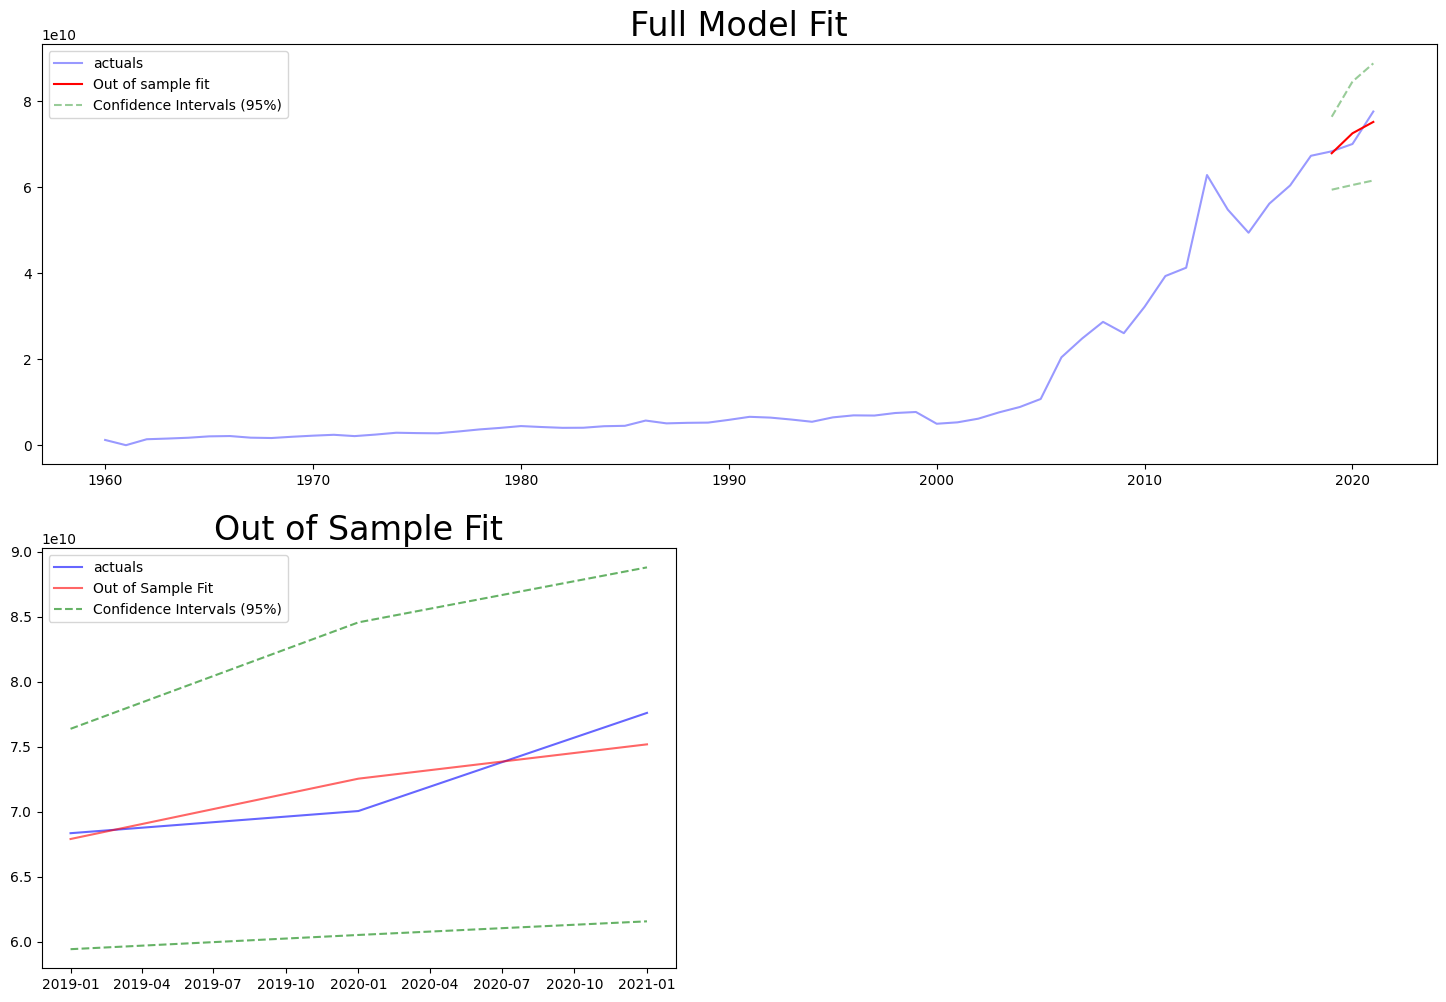

In [ ]:
plt.rcParams['figure.figsize'] = 18,12 

plt.subplot(2, 1, 1)

plt.plot(pred_df['GDP (current US$)'], color='blue', label='actuals', alpha=0.4)

plt.plot(
    pred_df.loc[test_df.index]['model_preds'],
    color='red',
    linestyle='-',
    label='Out of sample fit'
)

plt.plot(
    pred_df.loc[test_df.index]['model_preds_lower'],
    color='green',
    linestyle="--",
    label='Confidence Intervals (95%)',
    alpha=0.4,
)

plt.plot(
    pred_df.loc[test_df.index]['model_preds_upper'],
    color='green',
    linestyle="--",
    alpha=0.4,
)

plt.title('Full Model Fit', size=24)
plt.legend()

plt.subplot(2, 2, 3)

plt.plot(
    pred_df.loc[test_df.index]['GDP (current US$)'], color='blue', label='actuals', alpha=0.6
)

plt.plot(
    pred_df.loc[test_df.index]['model_preds'],
    color='red',
    linestyle="-",
    label='Out of Sample Fit',
    alpha=0.6,
)

plt.plot(
    pred_df.loc[test_df.index]['model_preds_lower'],
    color='green',
    linestyle="--",
    label='Confidence Intervals (95%)',
    alpha=0.6,
)

plt.plot(
    pred_df.loc[test_df.index]['model_preds_upper'],
    color='green',
    linestyle="--",
    alpha=0.6,
)

plt.title('Out of Sample Fit', size=24)
plt.legend()

plt.show()

Предсказанные данные ВВП Ганы за 2020, 2021 расходятся с реальными данными сильнее чем за 2019 год, но находятся в пределах доверительного интервала. Так точек всего 3 (3 года) данных недостаточно, чтобы определить качество построенной модели. Необходимо применеить downsampling для построений более тчоной модели. 

In [16]:
display(data.asfreq(freq='AS').isna().sum())
display(data.isna().sum())
data['GDP (current US$)'] = data['GDP (current US$)'].apply(lambda x: np.nan if x==0 else x)
display(data.isna().sum())
data['GDP (current US$)'].interpolate(method='linear', inplace=True)
display(data.isna().sum())

GDP (current US$)    0
dtype: int64

GDP (current US$)    0
dtype: int64

GDP (current US$)    1
dtype: int64

GDP (current US$)    0
dtype: int64

In [17]:
train_df = data.loc[:"2018-12-31"]
test_df = data.loc["2019-01-01":]

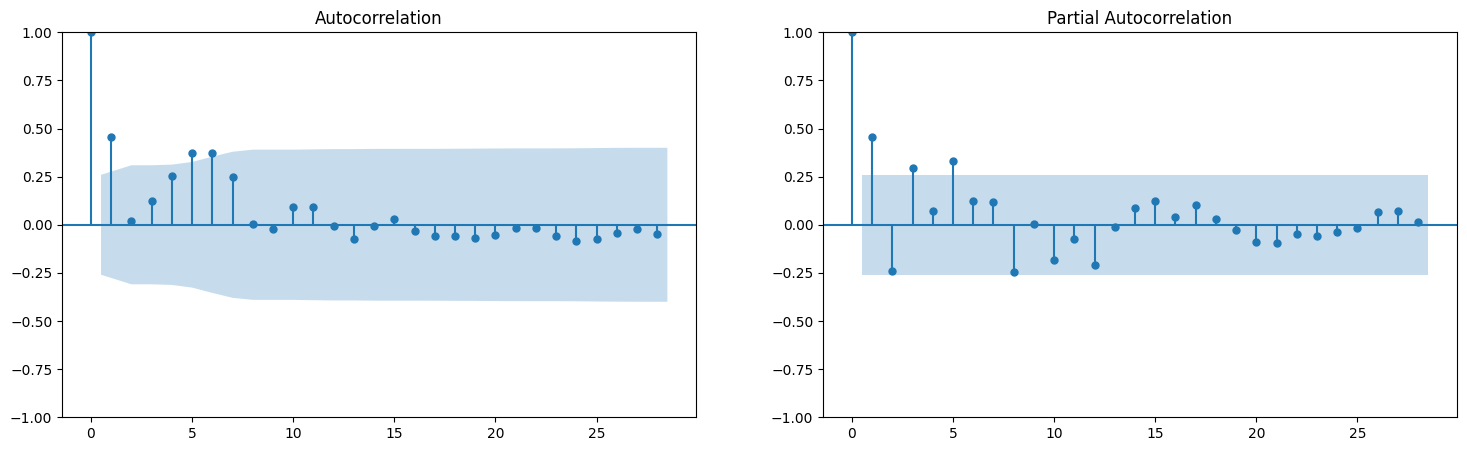

adf:  -3.9998034409491487
p-value:  0.0014115408436661348
Critical values:  {'1%': -3.584828853223594, '5%': -2.9282991495198907, '10%': -2.6023438271604937}
ряд стационарен


In [ ]:
plot_acf_pacf(train_df['GDP (current US$)'].diff(2).dropna(), 28)
get_adfuller(df=train_df.diff(2).dropna())

In [19]:
arima_model = ARIMA(train_df['GDP (current US$)'].dropna(), order=(1, 2, 1))
arima_model_fit = arima_model.fit()
arima_model_fit.summary()

c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:      GDP (current US$)   No. Observations:                   59
Model:                 ARIMA(1, 2, 1)   Log Likelihood               -1339.188
Date:                Mon, 24 Feb 2025   AIC                           2684.377
Time:                        07:26:36   BIC                           2690.506
Sample:                    01-01-1960   HQIC                          2686.759
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1750      0.082     -2.127      0.033      -0.336      -0.014
ma.L1         -0.8690      0.046    -19.050      0.000      -0.958      -0.780
sigma2       1.96e+19   2.13e-22   9.21e+40      0.000    1.96e+19    1.96e+19
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):               277.83
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):             480.68   Skew:                             1.36
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.5e+56. Standard errors may be unstable.
"""

Критерий AIC изменился незначительно (2684.416 -> 2684.377)

In [20]:
data['GDP (current US$)_vol'] = (data['GDP (current US$)'] - data['GDP (current US$)'].shift(1)) / data['GDP (current US$)'].shift(1)
data['GDP (current US$)_vol'].head()

year
1960-01-01         NaN
1961-01-01    0.067894
1962-01-01    0.063578
1963-01-01    0.114488
1964-01-01    0.123636
Name: GDP (current US$)_vol, dtype: float64

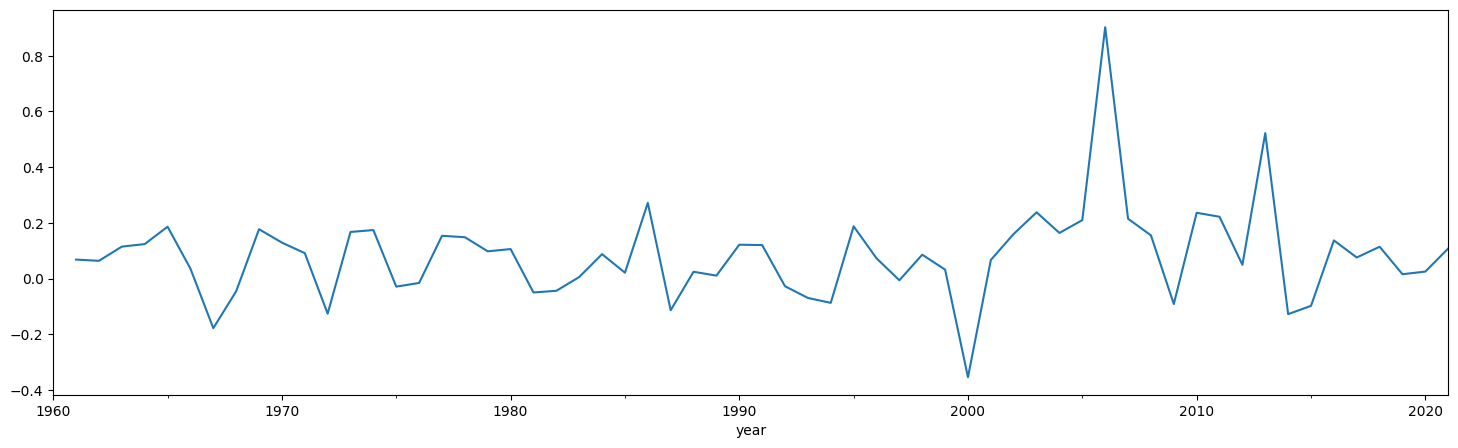

In [21]:
data['GDP (current US$)_vol'].plot()
plt.show()

In [22]:
train_df = data.loc[:"2018-12-31"]
test_df = data.loc["2019-01-01":]

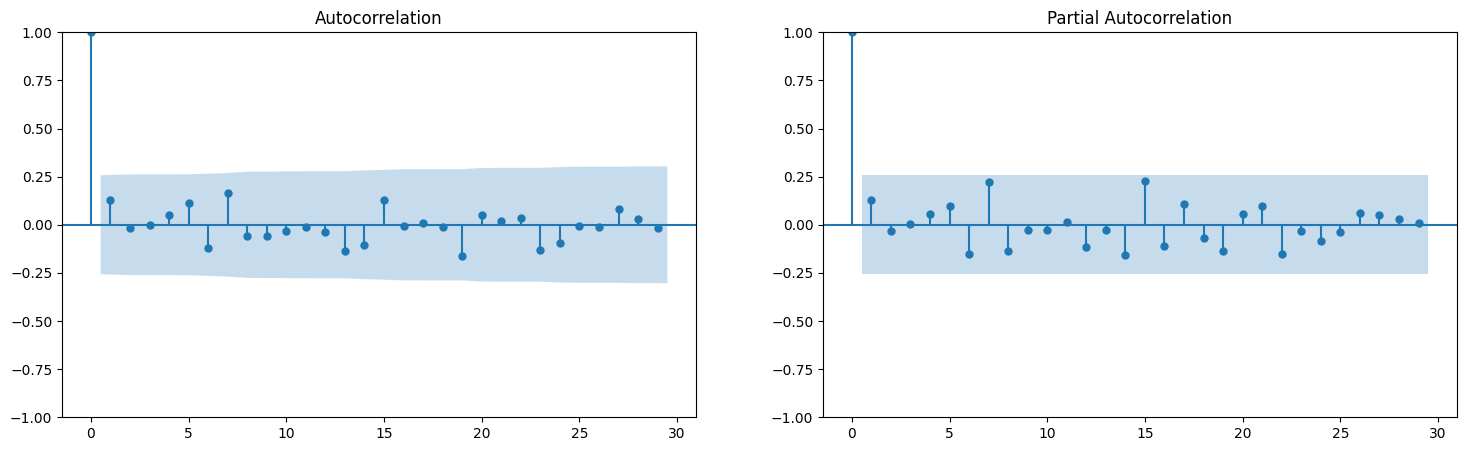

adf:  -6.520237104991782
p-value:  1.0465970681398587e-08
Critical values:  {'1%': -3.5506699942762414, '5%': -2.913766394626147, '10%': -2.5946240473991997}
ряд стационарен


In [23]:
plot_acf_pacf(train_df['GDP (current US$)_vol'].dropna(), 29)

get_adfuller(train_df['GDP (current US$)_vol'].dropna())

In [42]:
garch_df = pd.DataFrame(data['GDP (current US$)_vol'].loc[data.index])
garch_df.loc[train_df.index, 'GDP (current US$)_vol'] = train_df['GDP (current US$)_vol'].dropna()

In [43]:
model = arch_model(garch_df['GDP (current US$)_vol'].dropna(), p=7, q=7)
model_results = model.fit(last_obs=test_df.index[0], update_freq=5)

Iteration:      5,   Func. Count:     95,   Neg. LLF: 284.27493413533983
Iteration:     10,   Func. Count:    186,   Neg. LLF: -19.22683858913977
Iteration:     15,   Func. Count:    275,   Neg. LLF: -34.791028419748976
Iteration:     20,   Func. Count:    362,   Neg. LLF: -34.8094891204981
Iteration:     25,   Func. Count:    446,   Neg. LLF: -34.80979176670944
Optimization terminated successfully    (Exit mode 0)
            Current function value: -34.80979172701079
            Iterations: 25
            Function evaluations: 446
            Gradient evaluations: 25


c:\Users\romep\AppData\Local\Programs\Python\Python39\lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.02941. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [44]:
model_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                       Constant Mean - GARCH Model Results                       
=================================================================================
Dep. Variable:     GDP (current US$)_vol   R-squared:                       0.000
Mean Model:                Constant Mean   Adj. R-squared:                  0.000
Vol Model:                         GARCH   Log-Likelihood:                34.8098
Distribution:                     Normal   AIC:                          -37.6196
Method:               Maximum Likelihood   BIC:                          -4.65250
                                           No. Observations:                   58
Date:                   Mon, Feb 24 2025   Df Residuals:                       57
Time:                           07:35:25   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0877  1.133e-02      7.740  9.947e-15 [6.548e-02,  0.110]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      1.8759e-03  9.220e-03      0.203      0.839 [-1.620e-02,1.995e-02]
alpha[1]       0.0000      0.126      0.000      1.000      [ -0.247,  0.247]
alpha[2]       0.0000  4.736e-02      0.000      1.000 [-9.283e-02,9.283e-02]
alpha[3]   2.6142e-03  1.412e-02      0.185      0.853 [-2.505e-02,3.028e-02]
alpha[4]   3.0166e-13  1.810e-02  1.667e-11      1.000 [-3.547e-02,3.547e-02]
alpha[5]   1.0900e-03  1.711e-02  6.372e-02      0.949 [-3.244e-02,3.462e-02]
alpha[6]       0.4338      0.183      2.375  1.755e-02    [7.581e-02,  0.792]
alpha[7]       0.0729      0.308      0.237      0.813      [ -0.531,  0.677]
beta[1]        0.0656      0.543      0.121      0.904      [ -0.999,  1.130]
beta[2]    9.8206e-13      0.217  4.525e-12      1.000      [ -0.425,  0.425]
beta[3]        0.0000  7.925e-02      0.000      1.000      [ -0.155,  0.155]
beta[4]        0.0000      0.172      0.000      1.000      [ -0.336,  0.336]
beta[5]        0.0000  9.321e-02      0.000      1.000      [ -0.183,  0.183]
beta[6]        0.0000  5.953e-02      0.000      1.000      [ -0.117,  0.117]
beta[7]        0.4239      0.434      0.977      0.328      [ -0.426,  1.274]
=============================================================================

Covariance estimator: robust
"""

In [ ]:
predictions_df = test_df.copy()
predictions_df['Predictions'] = model_results.forecast().residual_variance.loc[
    test_df.index
]

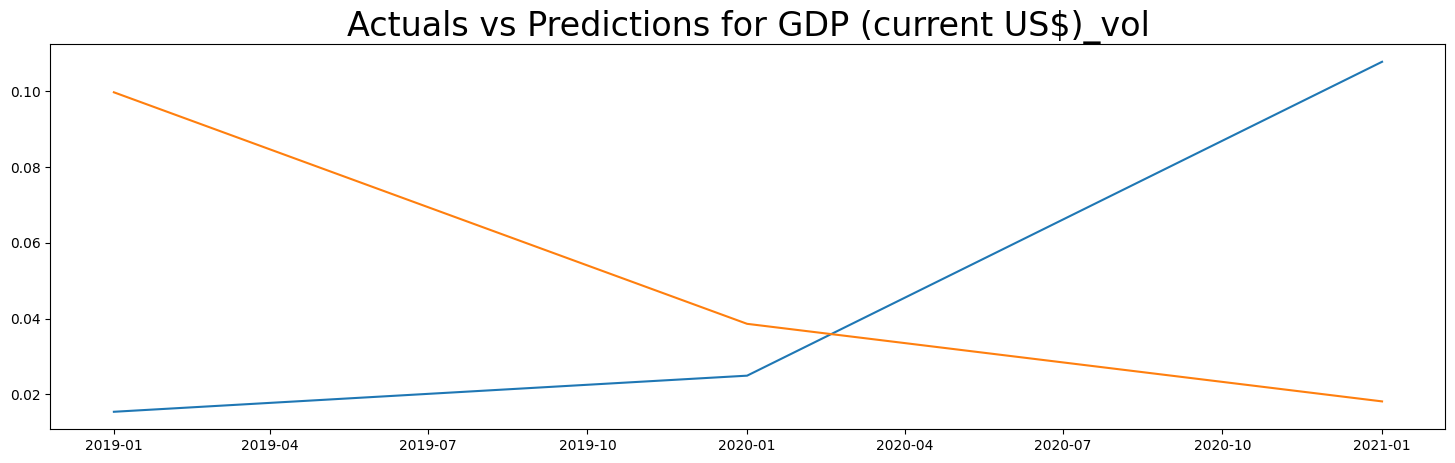

In [ ]:
plt.rcParams['figure.figsize'] = 18, 5

plt.plot(predictions_df['GDP (current US$)_vol'].abs())
plt.plot(predictions_df['Predictions'])

plt.title('Actuals vs Predictions for GDP (current US$)_vol', size=24)

plt.show()

Судя по полученному графику, модель не уловила дисперсию, так как такое поведение было для неё новым и подобные случаи отсутствовали в обучающей выборке.

In [47]:
mean_squared_error(predictions_df['GDP (current US$)_vol'].abs(), predictions_df['Predictions'])

0.005110945944915851

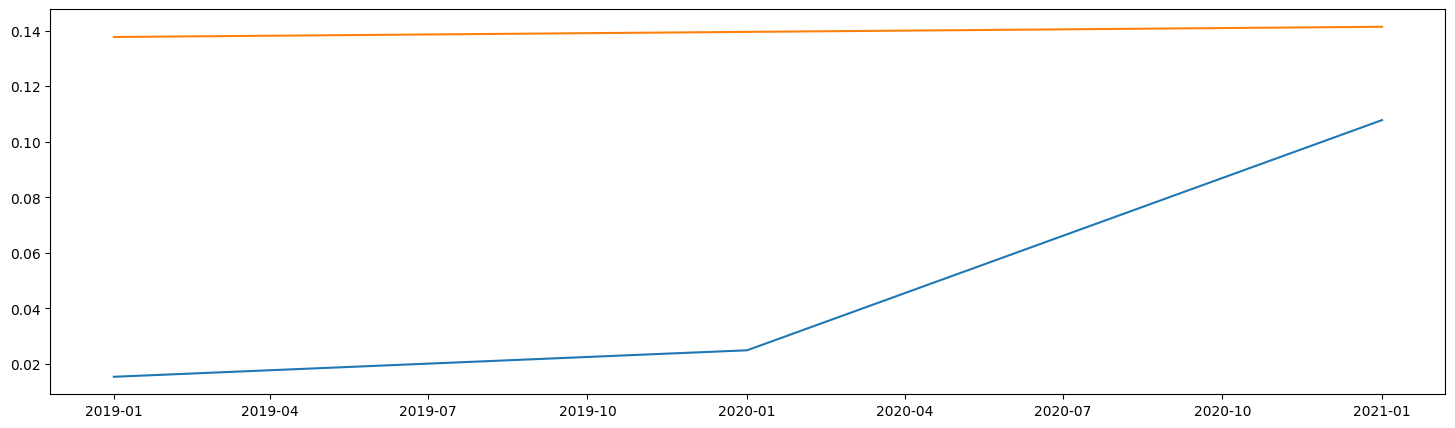

In [53]:
X_train = pd.DataFrame(range(data['GDP (current US$)_vol'].shape[0]))[
    : train_df.shape[0]
].fillna(0)
X_test = pd.DataFrame(range(data['GDP (current US$)_vol'].shape[0]))[
    train_df.shape[0] :
].fillna(0)
y_train = train_df['GDP (current US$)_vol'].fillna(0)
y_test = test_df['GDP (current US$)_vol'].fillna(0)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_predict = lr.predict(X_test)


plt.plot(y_test)
plt.plot(pd.Series(lr_predict, index=y_test.index))
plt.show()